#### Problem Statement

We want to build a system that can look at a face image and predict whether the person is wearing a mask or not.

Type of Problem

Image Classification

Binary Classification (2 classes)

Classes:

with_mask

without_mask

Why NOT normal programming?

Too many rules

Faces differ

Lighting & angles change

Why CNN?

CNN is designed for images

Learns patterns automatically

Best for computer vision    


“CNN learns features like eyes, nose, mouth, and mask edges.”

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator


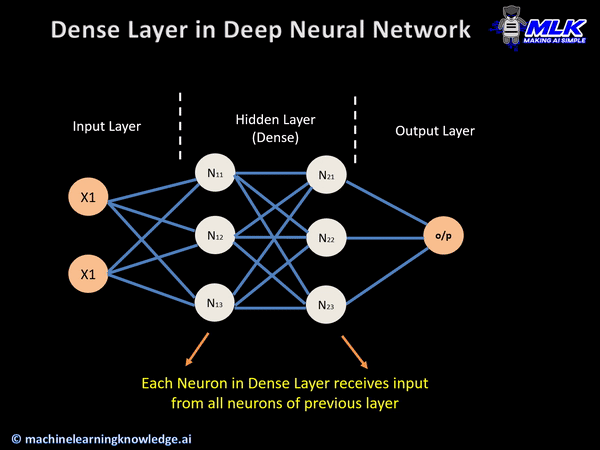
### TensorFlow
🔹 What is TensorFlow?

TensorFlow is a deep learning library

Developed to build AI & ML models

Handles all mathematical operations automatically

🔹 Why TensorFlow is used?

Works efficiently with large data

Supports GPU(graphic process unit )acceleration

Automatically computes:

Matrix multiplication

Gradients

Backpropagation.

TensorFlow is the engine that does all the heavy math work for deep learning. 

import tensorflow as tf

This single line gives access to:

Layers

Models

Optimizers

Loss functions.

### What is Sequential?

A model-building approach

Layers are added one after another.

#### Why Sequential?

Easy to understand

Best for beginner CNN models

Used when data flows in one direction

Like stacking LEGO blocks in a straight line.


### What is Conv2D? (Plain English)

Conv2D is the most important layer in a CNN.

👉 It:

Looks at small parts of an image

Uses filters (kernels) to scan the image

Finds important patterns



Conv2D helps the computer “see” the image by finding edges, shapes, and patterns.

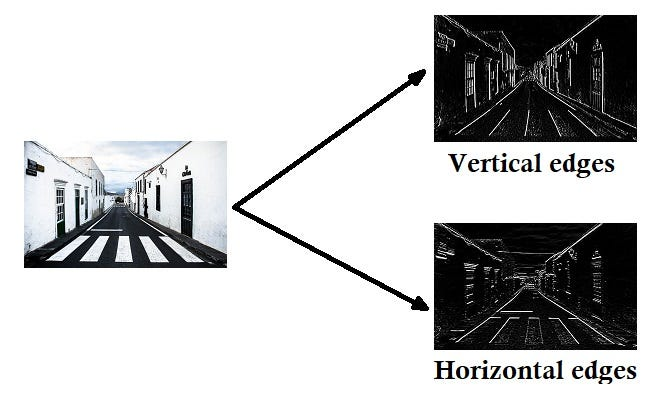

Why Conv2D is Needed?

Computers do not see images like humans.  Image = matrix of numbers

Conv2D:

Converts raw pixel values into meaningful features

Reduces unnecessary information

Keeps important visual details.

What is a Filter (Kernel)?

A filter is a small matrix of numbers.

Example filter (3×3):
1   0  -1
1   0  -1
1   0  -1

This filter is good at detecting vertical edges.

##### So Conv2D highlights edges automatically.

Human Eye Example

| Human            | CNN                |
| ---------------- | ------------------ |
| Eye scans object | Conv2D scans image |
| Notices edges    | Detects edges      |
| Sees shape       | Detects shapes     |


Why Multiple Filters are Used?

32 filters →

Some detect edges

Some detect curves

Some detect textures

📌 Each filter learns one type of feature.

Conv2D(32, (3,3), activation='relu').

What Happens in Deeper Layers?

| Layer          | Detects      |
| -------------- | ------------ |
| 1st Conv layer | Edges        |
| 2nd Conv layer | Shapes       |
| 3rd Conv layer | Object parts |
| Deep layers    | Full object  |

Example:

Face → eyes → nose → face

### MaxPooling2D
🔹 What is MaxPooling2D?

A downsampling layer

Reduces image size

Keeps only the most important information



MaxPooling makes the image smaller but keeps the strongest features.

🔹 Why MaxPooling is Needed?

Reduces computation

Makes model faster

Helps prevent overfitting

Keeps dominant features (edges, corners).

##### How MaxPooling Works.
1   3
2   5

Output:5


👉 Only the maximum value is kept.

answer should be .

Keeps only important points

Removes extra details
key points. 

| Feature     | Meaning          |
| ----------- | ---------------- |
| pool_size   | Area to pick max |
| Output size | Reduced          |
| Speed       | Faster model     |



### What is Flatten?

Converts 2D / 3D feature maps into 1D array

Used before Dense layer

📌 Student sentence:

Flatten converts image features into a long list of numbers.

🔹 Why Flatten is Needed?

Dense layer accepts only 1D input

Conv layers output 2D / 3D data

Visual Understanding

Matrix → Line

Image → Numbers.

from tensorflow.keras.layers import Flatten

Flatten()


### Dense (Fully Connected Layer)
🔹 What is Dense?

Fully connected layer

Every neuron connects to every input

Makes final decision

📌 One-line definition:

Dense layer decides what the image is.

🔹 How Dense Works (Simple Steps)

Takes flattened values

Multiplies with weights

Adds bias

Applies activation

Produces output.

#### Types of Dense Layers
🔸 Hidden Dense Layer:Learns patterns from the input 

Dense(128, activation='relu')

🔸 Output Dense Layer:Gives final prediction

Dense(1, activation='sigmoid')




how this works :

| CNN Layer  | Human Role   |
| ---------- | ------------ |
| Conv2D     | Eyes         |
| MaxPooling | Brain filter |
| Flatten    | Notes        |
| Dense      | Decision     |

Complete Flow (Tell Students)

Image → Conv2D → MaxPooling2D → Flatten → Dense → Prediction.

MaxPooling2D: Reduces image size while keeping important features

Flatten: Converts image data into 1D array

Dense: Fully connected layer that makes final decision


### ImageDataGenerator

Reads images from folders

Converts them into numbers

Applies preprocessing

📌 Student line:

“These libraries are our tools to build the brain.”

## DATA PREPROCESSING

What is preprocessing?

Preparing raw data so that model can learn properly.

In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


rescale=1./255

Original pixel values: 0–255

CNN works better with 0–1

Dividing by 255 normalizes the data

📌 Teaching line:

“Normalization helps the model learn faster.”

validation_split=0.2

80% data → training

20% data → validation

Validation data checks model performance

📌 Teaching line:

“Validation is like an exam for the model.”

## LOAD DATA FROM FOLDER

In [3]:
# Code (Training Data)

train_data = datagen.flow_from_directory(
  r"C:\Users\TEKS - 0058\Documents\projects\deep learning\face-mask-dataset", # "face-mask-dataset",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)


Found 708 images belonging to 2 classes.



1️⃣ "face-mask-dataset"

Main dataset folder

Contains class folders

2️⃣ target_size=(128,128)

All images resized to same size

CNN requires uniform input

📌 Teaching line:

“CNN cannot learn from different-sized images.”

3️⃣ batch_size=16

Model processes 16 images at a time

Saves memory.

4️⃣ class_mode='categorical'

Because we have 2 classes

Labels converted to one-hot encoding

with_mask → [1,0]
without_mask → [0,1]

5️⃣ subset='training'

Uses 80% images for training


## Validation Data Code

In [4]:
val_data = datagen.flow_from_directory(
    r"C:\Users\TEKS - 0058\Documents\projects\deep learning\face-mask-dataset",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)
#  but for validation images.

Found 176 images belonging to 2 classes.


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])


c:\Users\TEKS - 0058\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
import numpy as np

unique, counts = np.unique(train_data.classes, return_counts=True)
dict(zip(unique, counts))


{np.int32(0): np.int64(294), np.int32(1): np.int64(414)}

In [7]:
print(type(model))


<class 'keras.src.models.sequential.Sequential'>


## BUILD CNN MODEL

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),# Reduces size by half  Keeps strongest features  “Keeps important information, removes noise.”

    Conv2D(64, (3,3), activation='relu'),# Learns more complex features, Like mask shape, mouth area
    MaxPooling2D(2,2),

    Flatten(), #Converts image matrix into vector
    Dense(64, activation='relu'), # Brain of the model, Learns relationships
    Dense(2, activation='softmax') # 2 classes , Softmax gives probability
])


Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3))

32 filters → learns 32 patterns

(3×3) → small window

ReLU → removes negative values

Input shape → color image (RGB)

This layer learns edges and mask borders.”

## COMPILE MODEL

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.2040816326530612), 1: np.float64(0.855072463768116)}


Optimizer – Adam

Updates weights

Fast & efficient

Loss – categorical_crossentropy

Measures error

Used for classification

Accuracy

Shows correct predictions

## TRAIN MODEL

In [11]:
# model.fit(
#     train_data,
#     epochs=5,
#     validation_data=val_data
# )
model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    class_weight=class_weights
)



Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 312ms/step - accuracy: 0.9986 - loss: 0.0046 - val_accuracy: 0.8409 - val_loss: 0.6752
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.9972 - loss: 0.0071 - val_accuracy: 0.9261 - val_loss: 0.3184
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9205 - val_loss: 0.3839
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9261 - val_loss: 0.4463
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 270ms/step - accuracy: 1.0000 - loss: 5.3404e-04 - val_accuracy: 0.8920 - val_loss: 0.4327
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 264ms/step - accuracy: 1.0000 - loss: 2.8914e-04 - val_accuracy: 0.9148 - val_loss: 0.4402
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 282ms/step - accuracy: 1.0000 - loss: 2.2921e-04 - val_accuracy: 0.9148 - val_loss: 0.4522
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 1.0000 - loss: 2.149

Epoch

One complete learning cycle

Model improves every epoch


“More epochs = more learning (up to a limit).”

## SAVE MODEL

In [12]:

model.save("face_mask_model.h5")
# Why save?

# Training takes time

# Model reused later

# Needed for deploymen

## HOW MODEL MAKES PREDICTION

Prediction means:

Giving a new image to the trained model and asking for the output.

Model output is probabilities, not direct words.

With Mask: 0.93

Without Mask: 0.07
Model chooses highest value → With Mask ✅

### LOAD SAVED MODEL


Why load model?

Because:

Training is already done

We reuse the learned knowledge

In [13]:
from tensorflow.keras.models import load_model

model = load_model("face_mask_model.h5")


face_mask_model.h5 contains:

Learned weights

Model architecture

Loading = restoring trained brain

In [14]:
### LOAD A SINGLE IMAGE FOR TESTING .

# take image from file 
from PIL import Image
import numpy as np

img = Image.open(r"C:\Users\TEKS - 0058\Documents\projects\deep learning\face-mask-dataset\with_mask\with_mask_950.jpg").convert("RGB") 
img = img.resize((128,128))
img = np.array(img)/255.0


Image.open()

Opens image file

resize((128,128))

Same size as training images

CNN requires fixed input size

np.array(img)

Converts image → numbers

CNN understands only numbers

## PREPROCESS IMAGE

In [15]:
img = img / 255.0
img = img.reshape(1,128,128,3)


img / 255.0

Normalization

Same preprocessing as training

📌 Teaching line:

“Training and testing preprocessing must be SAME.”

reshape(1,128,128,3)

1 → one image

128×128 → image size

3 → RGB channels

CNN always expects batch input.

## PREDICT

In [16]:
prediction = model.predict(img)
prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


array([[0.10437471, 0.89562523]], dtype=float32)

Model returns probabilities

Order depends on class indices

In [17]:
train_data.class_indices


{'with_mask': 0, 'without_mask': 1}

In [18]:
print(train_data.class_indices)
{'with_mask': 1, 'without_mask': 0}

{'with_mask': 0, 'without_mask': 1}


{'with_mask': 1, 'without_mask': 0}

In [19]:
classes = ['With Mask', 'Without Mask']
print(classes[np.argmax(prediction)])
#“Argmax picks the highest probability.”

Without Mask


In [20]:
class_labels = {v:k for k,v in train_data.class_indices.items()}
print(class_labels)
predicted_class = np.argmax(prediction)
print("Prediction:", class_labels[predicted_class])

{0: 'with_mask', 1: 'without_mask'}
Prediction: without_mask


## DEPLOYMENT

What is Deployment?

Deployment means:

Using trained model in an application so users can interact with it.

WHY STREAMLIT?

Streamlit is used because:

Very simple

No frontend knowledge

Fast demo

Perfect for students